## EDA And Feature Engineering Of Google Play Store Dataset

1) Problem statement.
Today, 1.85 million different apps are available for users to download. Android users have even more from which to choose, with 2.56 million available through the Google Play Store. These apps have come to play a huge role in the way we live our lives today. Our Objective is to find the Most Popular Category, find the App with largest number of installs , the App with largest size etc.
2) Data Collection.

The data consists of 20 column and 10841 rows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('Data/googleplaystore.csv')

In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
df.shape

(10841, 13)

In [6]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [7]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

## Data Cleaning

In [8]:
df_copy=df.copy()

In [9]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [10]:
df_copy['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'],
      shape=(6002,), dtype=object)

In [11]:
df_copy['Reviews'].str.isnumeric().sum()

np.int64(10840)

In [12]:
df_copy[~df_copy['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [13]:
df_copy=df_copy.drop(10472)

In [14]:
df_copy['Reviews']=df_copy['Reviews'].astype(int)

In [15]:
df_copy['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [16]:
df_copy['Size']=df_copy['Size'].replace('Varies with device',np.nan)

In [17]:
is_k = df_copy["Size"].str.contains("k", na=False)

In [18]:
df_copy["Size"] = df_copy["Size"].str.replace("M", "").str.replace("k", "").astype(float)


In [19]:
df_copy.loc[is_k, "Size"] = df_copy.loc[is_k, "Size"] / 1024

In [20]:
df_copy['Size'].head(5)

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64

In [21]:
df_copy.head(2)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [22]:
df_copy['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [23]:
char_to_change=['+',',']
for char in char_to_change:
    df_copy['Installs']=df_copy['Installs'].str.replace(char,'')

df_copy['Installs']=df_copy['Installs'].astype(int)

In [24]:
df_copy['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [25]:
df_copy['Price']=df_copy['Price'].str.replace('$','').astype(float)

In [26]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.2+ MB


In [27]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [28]:
df_copy['Last Updated'].unique()

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      shape=(1377,), dtype=object)

In [29]:
df_copy['Last Updated']=pd.to_datetime(df_copy['Last Updated'])

In [30]:
df_copy['Day']=df_copy['Last Updated'].dt.day
df_copy['Month']=df_copy['Last Updated'].dt.month
df_copy['Year']=df_copy['Last Updated'].dt.year

In [31]:
df_copy.drop(columns='Last Updated',inplace=True)

In [32]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Current Ver     10832 non-null  object 
 11  Android Ver     10838 non-null  object 
 12  Day             10840 non-null  int32  
 13  Month           10840 non-null  int32  
 14  Year            10840 non-null  int32  
dtypes: float64(3), int32(3), int64(2), object(7)
memory usage: 1.2+ MB


## Adressing Null Values

In [33]:
df_copy = df_copy.dropna(subset=['Type','Current Ver','Android Ver'])

## DELETING DUPLICATES

In [ ]:
df_copy[df_copy.duplicated(subset='App')].shape

In [34]:
df_copy = df_copy.sort_values(by="Reviews", ascending=False)
df_copy=df_copy.drop_duplicates(subset='App',keep='first')

In [35]:
df_copy.shape

(9648, 15)

In [36]:
df_copy.isnull().sum()

App                  0
Category             0
Rating            1458
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Current Ver          0
Android Ver          0
Day                  0
Month                0
Year                 0
dtype: int64

In [37]:
df_copy.describe()

,Rating,Reviews,Size,Installs,Price,Day,Month,Year
count,8190.000000,9.648000e+03,8421.000000,9.648000e+03,9648.000000,9648.000000,9648.000000,9648.000000
mean,4.173346,2.170487e+05,20.416740,7.806898e+06,1.098122,15.621891,6.365361,2017.346704
std,0.536319,1.832460e+06,21.834545,5.379975e+07,16.861193,9.431111,2.660093,1.136906
min,1.000000,0.000000e+00,0.008301,0.000000e+00,0.000000,1.000000,1.000000,2010.000000
25%,4.000000,2.500000e+01,4.600000,1.000000e+03,0.000000,7.000000,5.000000,2017.000000
50%,4.300000,9.745000e+02,12.000000,1.000000e+05,0.000000,16.000000,7.000000,2018.000000
75%,4.500000,2.949750e+04,28.000000,1.000000e+06,0.000000,24.000000,8.000000,2018.000000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000,31.000000,12.000000,2018.000000


In [38]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Day,Month,Year
2544,Facebook,SOCIAL,4.1,78158306,NaN,1000000000,Free,0.0,Teen,Social,Varies with device,Varies with device,3,8,2018
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,NaN,1000000000,Free,0.0,Everyone,Communication,Varies with device,Varies with device,3,8,2018


In [39]:
df_copy['Rating']=df_copy['Rating'].fillna(df_copy.groupby('Category')['Rating'].transform('median'))


In [40]:
df_copy['Size']=df_copy['Size'].fillna(df_copy.groupby('Category')['Size'].transform('median'))

In [41]:
df_copy.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Current Ver       0
Android Ver       0
Day               0
Month             0
Year              0
dtype: int64

## Choosing Imputation method for filling nan values
- For Rating mean < median and the data is left skewed. For Size mean > median and the data is right skewed.
  So i used  median to fill the null values because it is robust to oultiers ensuring that the extreme values
  in skewed columns does not bias the missing data


In [42]:
df_copy.to_csv('Data/google_playstore_cleaned.csv')

In [43]:
df_copy.shape

(9648, 15)

## EDA

In [44]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Day,Month,Year
2544,Facebook,SOCIAL,4.1,78158306,7.9,1000000000,Free,0.0,Teen,Social,Varies with device,Varies with device,3,8,2018
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,5.7,1000000000,Free,0.0,Everyone,Communication,Varies with device,Varies with device,3,8,2018


## DISTRIBUTION OF NUMERIC FEATURES

In [45]:
numeric_features=[column for column in df_copy.columns if df_copy[column].dtype != 'O']
category_features=[column for column in df_copy.columns if df_copy[column].dtype=='O']

print('The {} Numeric Features are : {}'.format(len(numeric_features),numeric_features))
print('The {} Category Features are : {}'.format(len(category_features),category_features))

The 8 Numeric Features are : ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Day', 'Month', 'Year']
The 7 Category Features are : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


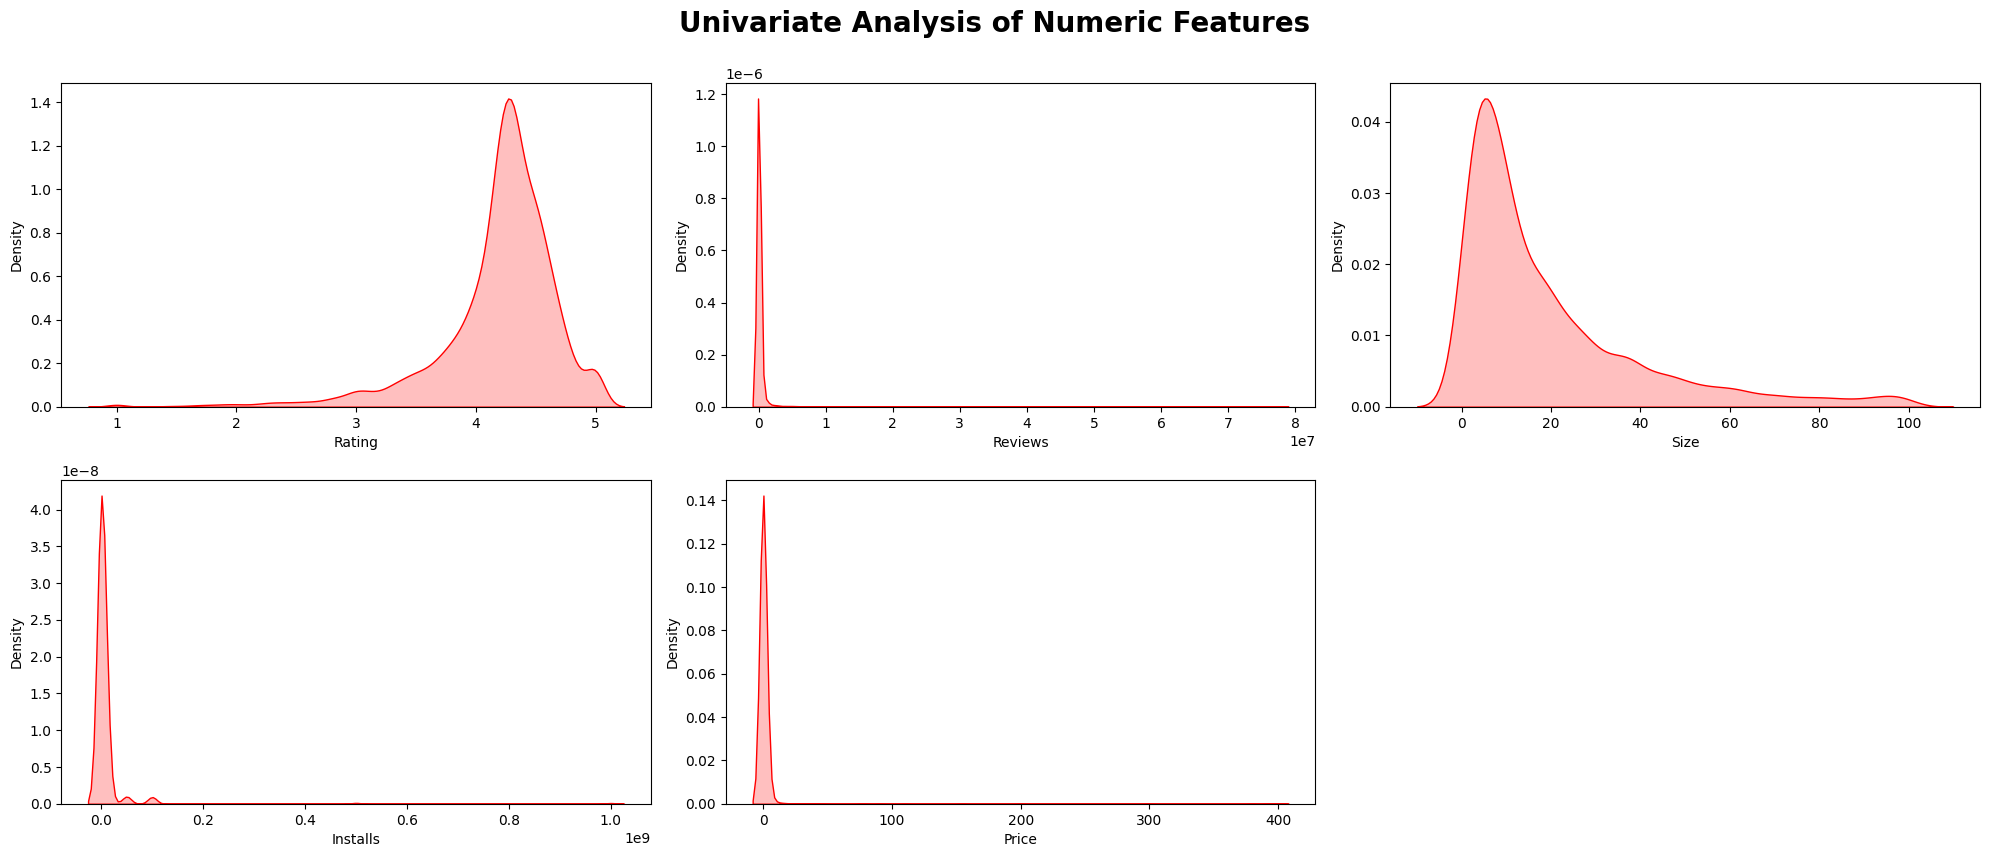

In [46]:
plt.figure(figsize=(20,20))
plt.suptitle('Univariate Analysis of Numeric Features',fontsize=20,fontweight='bold',y=1)
numeric_features = ['Rating', 'Reviews', 'Size', 'Installs', 'Price']
for i in range(0,len(numeric_features)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=numeric_features[i],color='r',shade=True,data=df_copy)
    plt.xlabel(numeric_features[i])
    plt.tight_layout()
    plt.savefig('Images/numeric_distribution.png',bbox_inches='tight')

## Insights
- Ratings are left skewed with high values between(4.0 to 4.7), while Reviews, Size, Prize and Installs are right
  skewed. This shows that market is dominated by high rated apps.

## DISTRIBUTION OF CATEGORICAL FEATURES

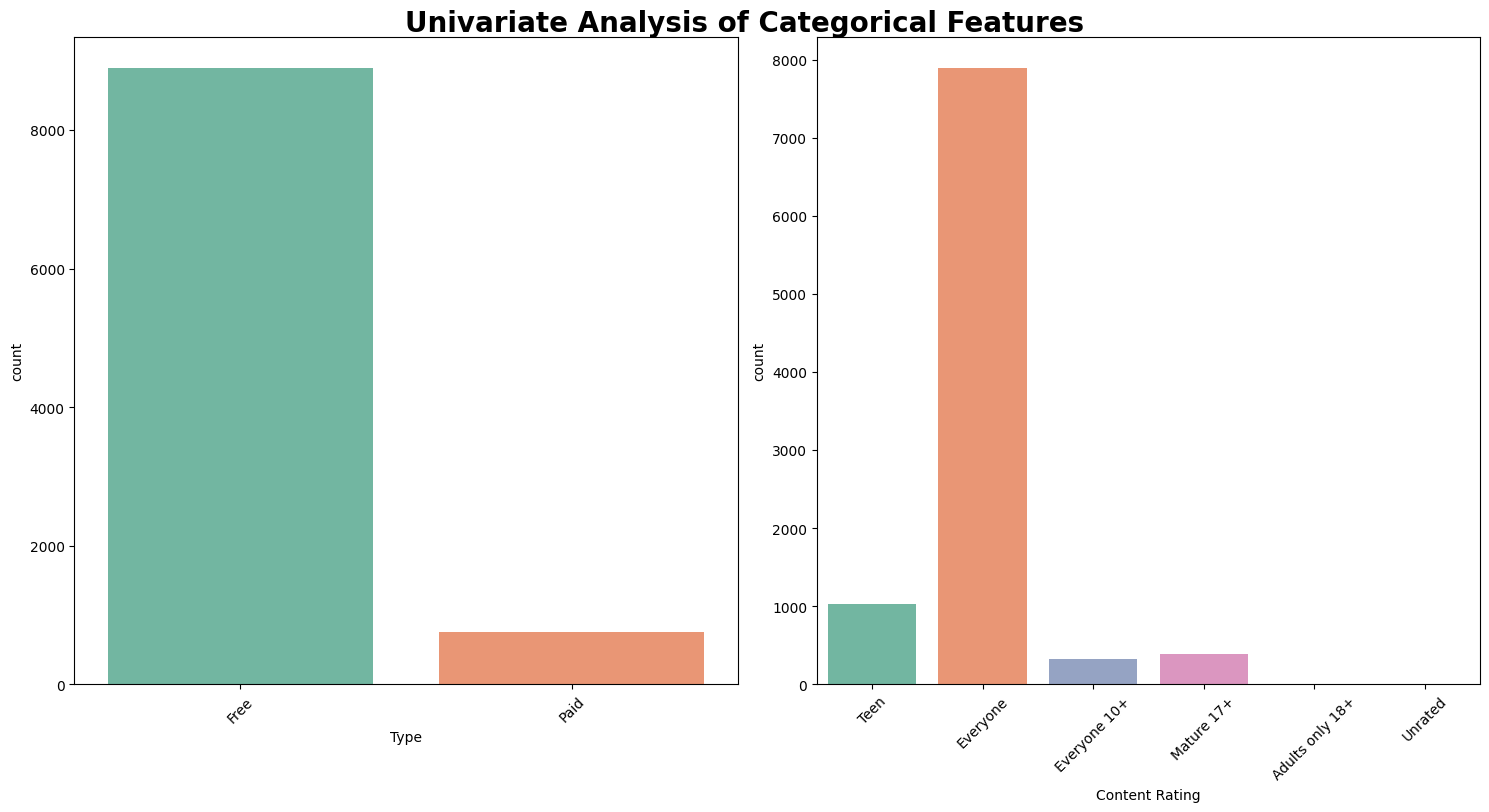

In [47]:

plt.figure(figsize=(15,15))
plt.suptitle('Univariate Analysis of Categorical Features',fontsize=20,fontweight='bold')
category = [ 'Type', 'Content Rating']
for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=category[i],palette="Set2",data=df_copy)
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout() 
    plt.savefig('Images/Category_analysis.png',bbox_inches='tight')

## Observations

1. Free apps completely dominate the Play Store capturing over 90% of the total volume. Paid apps make up an incredibly small minority.
2. The "Everyone" content rating is the largest category, all combined.

## TOP 10 APP CATEGORIES



In [48]:
category=df_copy['Category'].value_counts().head(10).reset_index()
category

,Category,count
0,FAMILY,1873
1,GAME,946
2,TOOLS,827
3,BUSINESS,420
4,MEDICAL,395
5,PRODUCTIVITY,374
6,PERSONALIZATION,374
7,LIFESTYLE,369
8,FINANCE,345
9,SPORTS,325


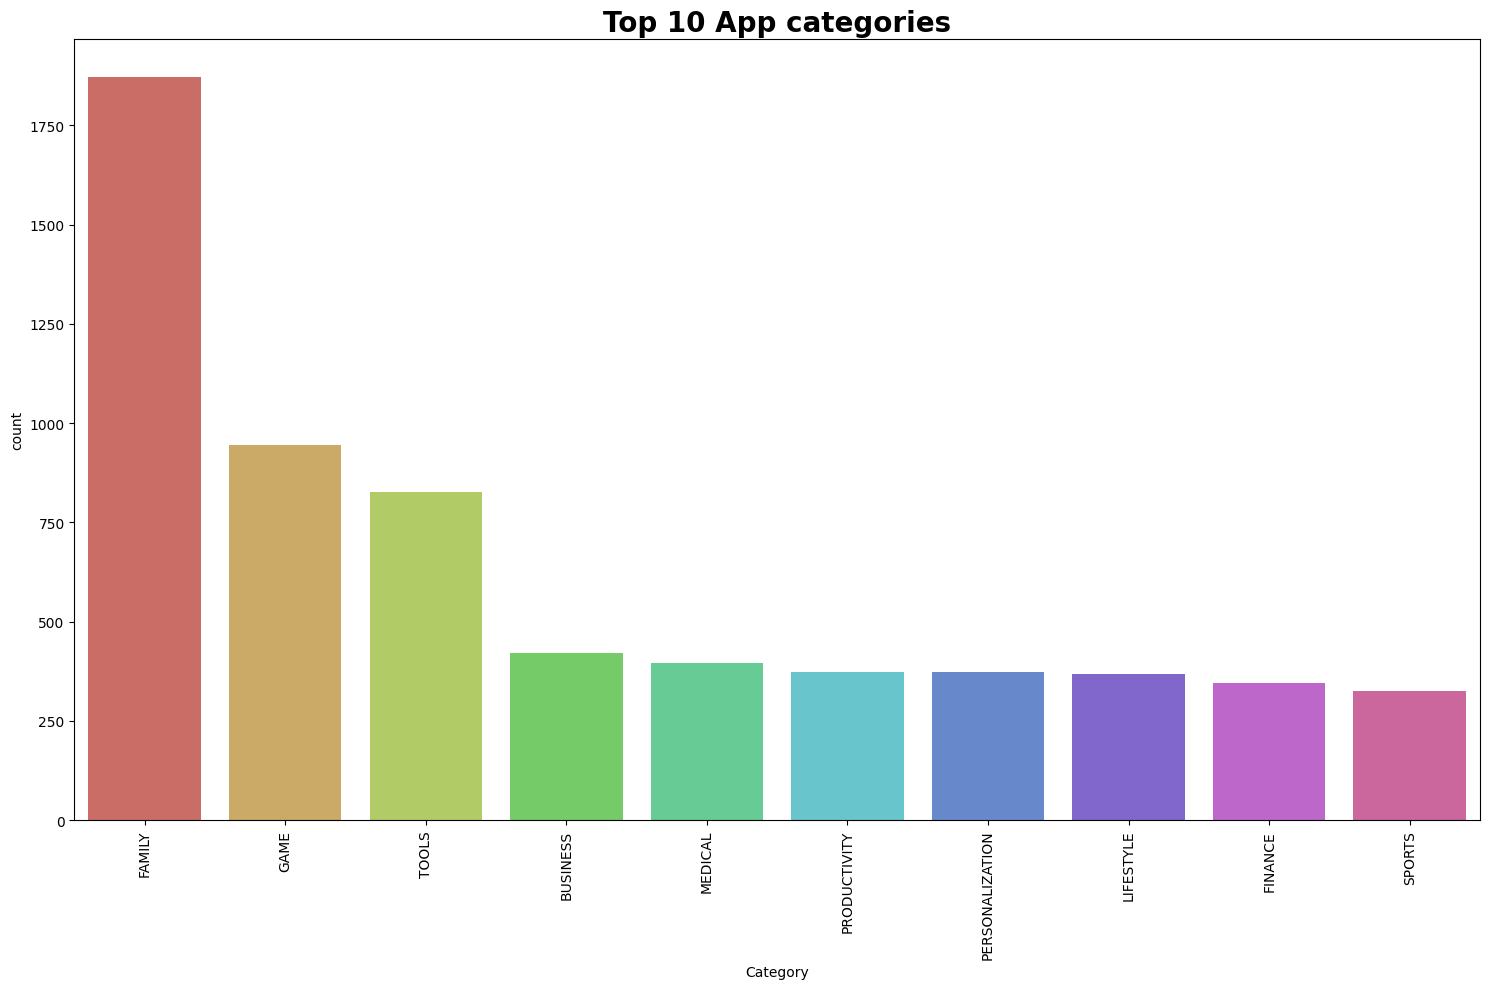

In [49]:
plt.figure(figsize=(15,10))
sns.barplot(x='Category',y='count',data=category,palette='hls')

plt.title('Top 10 App categories',fontsize=20,fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Images/top10_apps.png',bbox_inches='tight')
plt.show()


## Which Category has largest number of installations??


In [50]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Day,Month,Year
2544,Facebook,SOCIAL,4.1,78158306,7.9,1000000000,Free,0.0,Teen,Social,Varies with device,Varies with device,3,8,2018
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,5.7,1000000000,Free,0.0,Everyone,Communication,Varies with device,Varies with device,3,8,2018


In [51]:
top_categories=df_copy.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10).reset_index()
top_categories

,Category,Installs
0,GAME,13457924415
1,COMMUNICATION,11038276251
2,TOOLS,8102271905
3,FAMILY,6227482405
4,PRODUCTIVITY,5793091369
5,SOCIAL,5487867902
6,PHOTOGRAPHY,4658147655
7,VIDEO_PLAYERS,3931902720
8,TRAVEL_AND_LOCAL,2894887146
9,NEWS_AND_MAGAZINES,2369217760


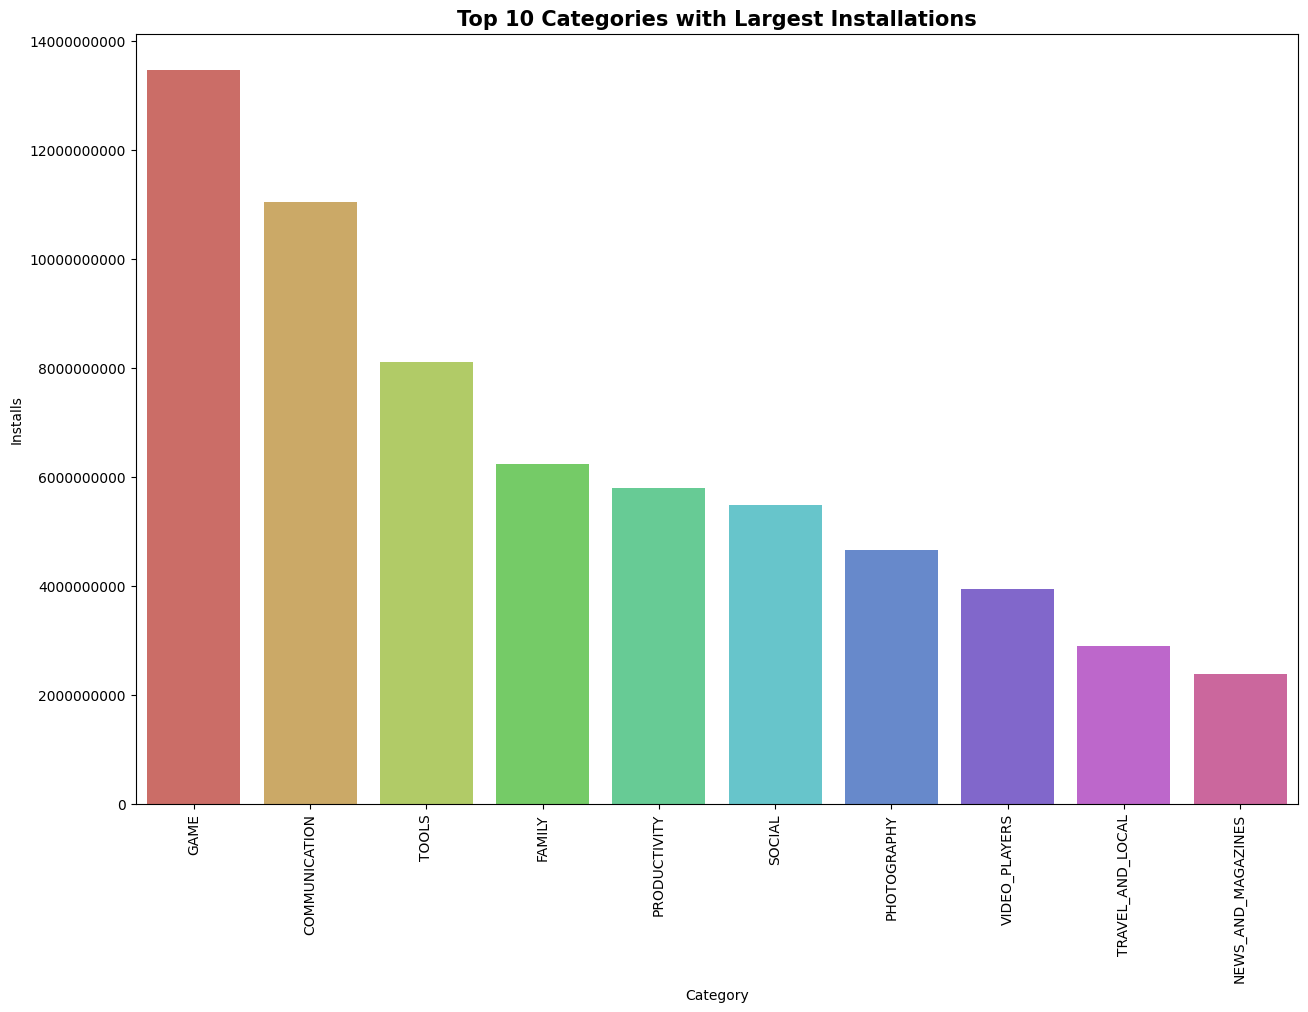

In [52]:
plt.figure(figsize=(15,10))
plt.title('Top 10 Categories with Largest Installations',fontsize=15,fontweight='bold')
sns.barplot(x='Category',y='Installs',palette='hls',data=top_categories)
plt.xticks(rotation=90)
plt.gca().ticklabel_format(style="plain", axis="y")
plt.savefig('Images/large_installs.png',bbox_inches='tight')
plt.show()


## Insights

Game has the largest number of installations among all categories. It has about 1.4 billion Installations.

## How many apps are there on Google Play Store which get 5 ratings??

In [53]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Day,Month,Year
2544,Facebook,SOCIAL,4.1,78158306,7.9,1000000000,Free,0.0,Teen,Social,Varies with device,Varies with device,3,8,2018
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,5.7,1000000000,Free,0.0,Everyone,Communication,Varies with device,Varies with device,3,8,2018


In [54]:
top_rating=df_copy[df_copy['Rating']==5.0]
print('Number of Apps with 5.0 rating are',top_rating.shape[0])

Number of Apps with 5.0 rating are 271


## Insights
There are 271 apps with 5.0 rating

## Correlation Analysis

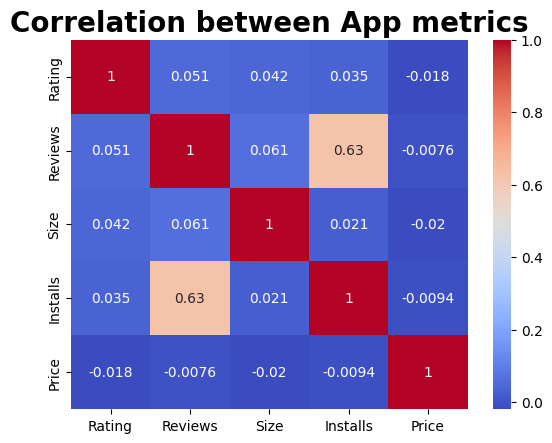

In [55]:
numeric_df=df_copy.select_dtypes(include=['float64','int64'])
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation between App metrics',fontsize=20,fontweight='bold')
plt.savefig('Images/correlation_analysis.png',bbox_inches='tight')
plt.show()


## Insights
- There is a strong positive correlation between Reviews and Installs. It suggest that writing reviews leads to 
  large number of installs.

## Time Series Analysis

In [56]:
yearly_counts=df_copy['Year'].value_counts().sort_index().reset_index()
yearly_counts


,Year,count
0,2010,1
1,2011,15
2,2012,26
3,2013,107
4,2014,203
5,2015,448
6,2016,777
7,2017,1789
8,2018,6282


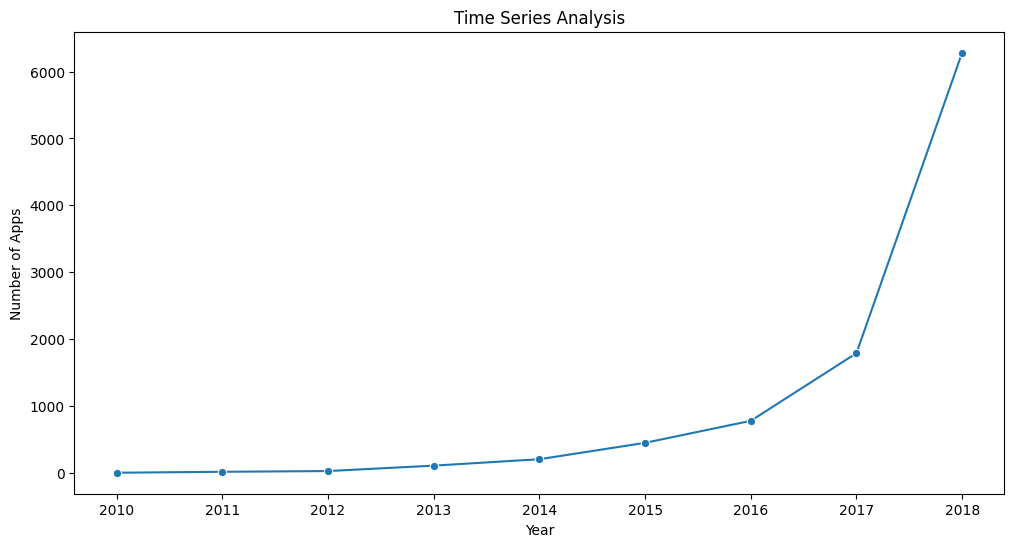

In [57]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Year',y='count',data=yearly_counts,marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Apps')
plt.title('Time Series Analysis')
plt.savefig('Images/Time_analysis.png',bbox_inches='tight')

## Insights
- The data shows an exponential growth with around 6000 apps updated in 2018